# Computer Exercise 6.3 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 6.3 B-Splines: Interpolation and Approximation — *지역 지지 (local support)*
> **풀이 일자**: Day 25
> **언어**: Python 3 (NumPy / SciPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Compare B-spline approximation with global polynomial (Lagrange)
> interpolation in the following experiment. Choose $n+1$ data points
> $\{(x_i, y_i)\}_{i=0}^n$ on a function $f(x)$. Perturb a *single* value
> $y_j \mapsto y_j + \delta$. Compute (a) the cubic B-spline curve through
> the perturbed data, and (b) the Lagrange polynomial $p_n$ through the
> perturbed data. Plot the *difference* between the perturbed and unperturbed
> curves. Observe that the B-spline difference is **nonzero only in a
> neighborhood of $x_j$**, whereas the polynomial difference is **nonzero
> everywhere**, with magnitude that can grow far from $x_j$.

### 한국어 풀이용 정리
B-spline 의 *지역 지지* 가 갖는 실용적 효과: *데이터 한 점* 의 값이 바뀌면 그 영향이
*$k+1$ 구간* 으로 한정된다. 반대로 전역 Lagrange 다항식은 한 점의 값이 바뀌면
*전 구간의 모든 계수* 가 바뀐다.

$n + 1$ 점 데이터를 만들고, 가운데 한 점만 $\delta = 1$ 만큼 흔든다.
*cubic B-spline* 보간 곡선과 *전역 Lagrange* 다항식 곡선의 *섭동 - 원본* 차이를
나란히 그려서, **국소성 vs 전역성** 을 시각적으로 직접 본다.


## 2. 수학적 배경

### 2.1 영향 함수 (influence function)

보간 연산자 $L$ 은 *데이터 -> 함수* 의 *선형* 사상이다. $L$ 의 *데이터 한 점에 대한 감응도* 는

$$
\boxed{\;
\frac{\partial L[\mathbf{y}](x)}{\partial y_j}
\;=\; L_j(x)
\;}
$$

— 즉 $L_j(x)$ 가 *$j$-번째 영향 함수*. 데이터를 $y_j \mapsto y_j + \delta$ 로 흔들면
보간 곡선은 정확히

$$
\Delta L(x) \;=\; \delta \cdot L_j(x)
$$

만큼 바뀐다. 따라서 *섭동의 자취* 가 곧 $\delta \cdot L_j(x)$ 의 그래프 — 영향 함수의 *모양 그 자체*.

### 2.2 Cubic B-spline 보간의 영향 함수

cubic B-spline 보간자에서 $L_j(x)$ 는 다시 *cubic B-spline 의 선형결합* 으로 표현된다. *지역 지지*

$$
\operatorname{supp} B_{i, 3} \;=\; [t_i, t_{i+4}]
$$

때문에, 보간 시스템이 *띠 행렬* 이고, 한 점의 변화가 $j$ 근처 *몇 개의 계수* 만 의미 있게
흔든다. 결과적으로 $|L_j(x)|$ 는 $x_j$ 에서 멀어질수록 *지수적으로 감쇠*. 따라서 섭동 곡선

$$
\Delta S(x) \;=\; \delta \cdot L_j^{\text{spline}}(x)
$$

는 *$x_j$ 근방의 좁은 종 모양*.

### 2.3 Lagrange 보간의 영향 함수

전역 다항식의 경우 영향 함수가 곧 **Lagrange 기저**

$$
L_j^{\text{poly}}(x) \;=\; \ell_j(x) \;=\; \prod_{i \ne j} \frac{x - x_i}{x_j - x_i}.
$$

이 함수는 $n$차 다항식 — **모든 $x$ 에서 일반적으로 0 이 아니다**.
게다가 *균등 격자* 의 경우 끝점 근처에서 $|\ell_j(x)|$ 가 *지수적으로 커진다* (Runge 와 같은 메커니즘).
따라서 같은 $\delta$ 의 섭동이 *끝점에서 수십 배 증폭*.

### 2.4 두 영향 함수의 정량 비교

같은 $n + 1$ 점, 같은 $\delta$ 의 한 점 섭동에 대해:

$$
\frac{\|\Delta L\|_\infty}{|\delta|}
\;=\;
\max_x |L_j(x)|
\;=\;
\Lambda_j.
$$

- cubic B-spline: $\Lambda_j^{\text{spline}}$ 는 $j$ 와 $n$ 에 *거의 무관* 하게 *$\mathcal O(1)$* (전형적으로 1 보다 약간 작거나 큼).
- 전역 Lagrange (균등 노드): $\Lambda_j^{\text{poly}}$ 는 $n$ 에 *기하급수적으로* 증가.

이것이 §6.3 의 핵심 *robustness* — *지역 지지* = *데이터 노이즈에 대한 안정성*.


## 3. 풀이 흐름

1. 함수 $f(x) = e^{-x^2/4}\cos(\pi x / 3)$ 을 $[-5, 5]$ 위에서 $n + 1 = 11$ 개 균등 노드로 샘플.
2. 가운데 점 $x_j = 0$ 에서 $y_j$ 에 $\delta = 1$ 더한 *섭동 데이터* 준비.
3. cubic B-spline 보간 (SciPy `CubicSpline`, not-a-knot — Day 24 결론과 동일한 BC).
4. 전역 Lagrange 다항식 보간 (NumPy `polyfit` deg = $n$).
5. 미세 격자에서 *원본 곡선, 섭동 곡선, 그 차이* 를 각각 평가.
6. 차이 곡선을 한 그림에 두 곡선으로 — B-spline 의 *국소 종*, Lagrange 의 *전구간 진동* 을 정면 비교.
7. **정량 표**: $\|\Delta\|_\infty$ 와 $\delta$ 의 비율 ($= \Lambda_j$), 그리고 차이가 $0.05 \cdot |\delta|$ 이상인 *영역의 길이* — *국소성 지표*.
8. $n$ 을 키우면서 (= 더 조밀한 데이터) Lagrange 의 $\Lambda_j$ 가 *기하급수적* 으로 커지는지 확인.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

pd.set_option("display.float_format", lambda v: f"{v:.6e}")
pd.set_option("display.precision", 6)


def f(x):
    return np.exp(-x ** 2 / 4) * np.cos(np.pi * x / 3)


a, b = -5.0, 5.0
n_pts = 11
x_data = np.linspace(a, b, n_pts)
y_data = f(x_data)

j = n_pts // 2
delta = 1.0
y_pert = y_data.copy()
y_pert[j] += delta

x_eval = np.linspace(a, b, 4001)

spl_orig = CubicSpline(x_data, y_data, bc_type="not-a-knot")
spl_pert = CubicSpline(x_data, y_pert, bc_type="not-a-knot")
y_spl_orig = spl_orig(x_eval)
y_spl_pert = spl_pert(x_eval)
dy_spline = y_spl_pert - y_spl_orig

coef_orig = np.polyfit(x_data, y_data, n_pts - 1)
coef_pert = np.polyfit(x_data, y_pert, n_pts - 1)
y_poly_orig = np.polyval(coef_orig, x_eval)
y_poly_pert = np.polyval(coef_pert, x_eval)
dy_poly = y_poly_pert - y_poly_orig

print(f"Data points: n + 1 = {n_pts}")
print(f"Perturbed index j = {j}, x_j = {x_data[j]:.1f}, delta = {delta}")
print()
print(f"max |delta_spline| = {np.max(np.abs(dy_spline)):.4f}")
print(f"max |delta_poly|   = {np.max(np.abs(dy_poly)):.4f}")


/tmp/mplcache is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ac1ablal because there was an issue with the default path (/tmp/mplcache); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Data points: n + 1 = 11
Perturbed index j = 5, x_j = 0.0, delta = 1.0

max |delta_spline| = 1.0000
max |delta_poly|   = 6.1461


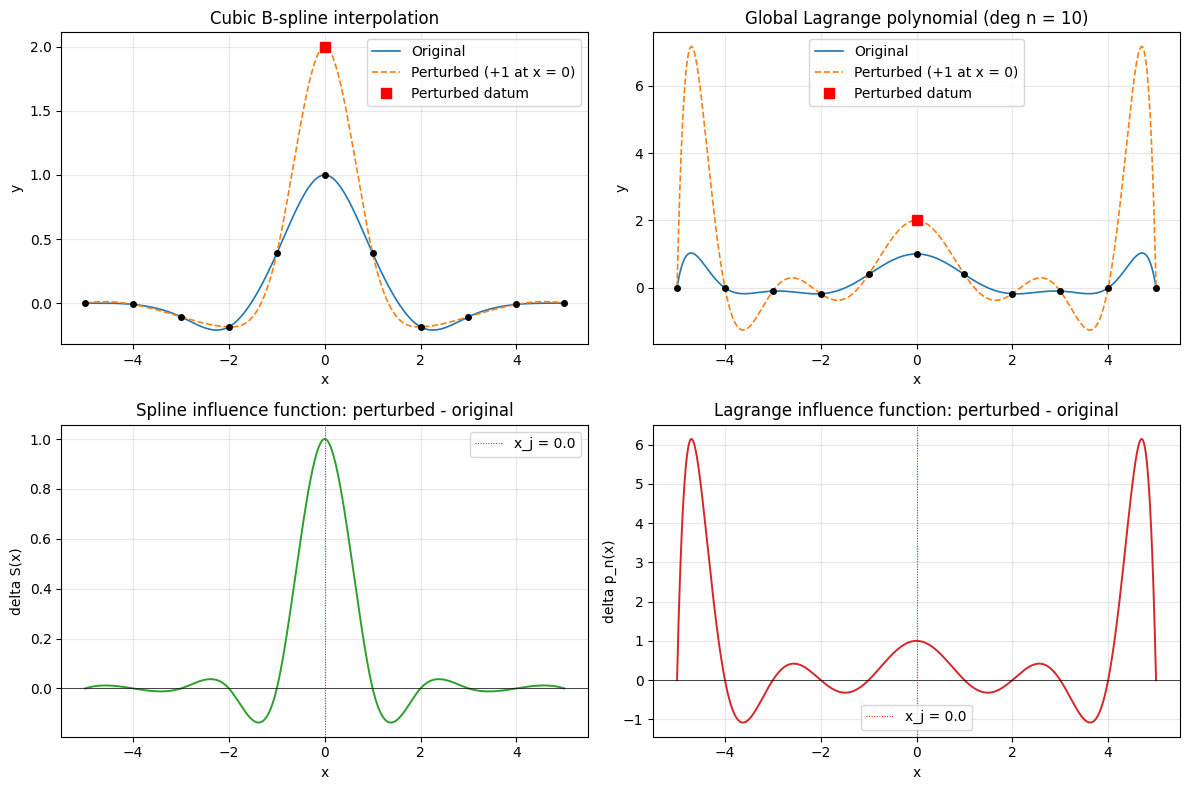

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.plot(x_eval, y_spl_orig, lw=1.2, label="Original")
ax.plot(x_eval, y_spl_pert, lw=1.2, ls="--", label="Perturbed (+1 at x = 0)")
ax.plot(x_data, y_data, "ko", ms=4)
ax.plot([x_data[j]], [y_pert[j]], "rs", ms=7, label="Perturbed datum")
ax.set_title("Cubic B-spline interpolation")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(x_eval, y_poly_orig, lw=1.2, label="Original")
ax.plot(x_eval, y_poly_pert, lw=1.2, ls="--", label="Perturbed (+1 at x = 0)")
ax.plot(x_data, y_data, "ko", ms=4)
ax.plot([x_data[j]], [y_pert[j]], "rs", ms=7, label="Perturbed datum")
ax.set_title("Global Lagrange polynomial (deg n = 10)")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(x_eval, dy_spline, lw=1.4, color="C2")
ax.axhline(0, color="black", lw=0.5)
ax.axvline(x_data[j], color="red", lw=0.7, ls=":", label=f"x_j = {x_data[j]:.1f}")
ax.set_title("Spline influence function: perturbed - original")
ax.set_xlabel("x"); ax.set_ylabel("delta S(x)")
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(x_eval, dy_poly, lw=1.4, color="C3")
ax.axhline(0, color="black", lw=0.5)
ax.axvline(x_data[j], color="red", lw=0.7, ls=":", label=f"x_j = {x_data[j]:.1f}")
ax.set_title("Lagrange influence function: perturbed - original")
ax.set_xlabel("x"); ax.set_ylabel("delta p_n(x)")
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [3]:
def locality(x_eval, dy, delta, tol_frac=0.05):
    sup = np.max(np.abs(dy)) / abs(delta)
    mask = np.abs(dy) > tol_frac * abs(delta)
    if not np.any(mask):
        width = 0.0
    else:
        idx = np.where(mask)[0]
        width = x_eval[idx.max()] - x_eval[idx.min()]
    return sup, width


sup_s, w_s = locality(x_eval, dy_spline, delta)
sup_p, w_p = locality(x_eval, dy_poly, delta)

domain_length = b - a
df = pd.DataFrame({
    "method": ["Cubic B-spline (not-a-knot)", "Lagrange polynomial (deg 10)"],
    "Lambda_j": [sup_s, sup_p],
    "effective support width (|delta| > 5% delta)": [w_s, w_p],
    "fraction of domain affected": [w_s / domain_length, w_p / domain_length],
})
df


,method,Lambda_j,effective support width (|delta| > 5% delta),fraction of domain affected
0,Cubic B-spline (not-a-knot),1.000000e+00,3.620000e+00,3.620000e-01
1,Lagrange polynomial (deg 10),6.146142e+00,9.995000e+00,9.995000e-01


In [4]:
ns = [6, 8, 10, 12, 14, 16, 18, 20]
records = []
for n in ns:
    xs = np.linspace(a, b, n + 1)
    ys = f(xs)
    j_mid = (n + 1) // 2
    ys_p = ys.copy(); ys_p[j_mid] += delta

    s0 = CubicSpline(xs, ys, bc_type="not-a-knot")(x_eval)
    s1 = CubicSpline(xs, ys_p, bc_type="not-a-knot")(x_eval)
    L_s = np.max(np.abs(s1 - s0)) / abs(delta)

    c0 = np.polyfit(xs, ys, n)
    c1 = np.polyfit(xs, ys_p, n)
    L_p = np.max(np.abs(np.polyval(c1, x_eval) - np.polyval(c0, x_eval))) / abs(delta)

    records.append({"n+1 = data points": n + 1,
                    "Lambda_j (spline)": L_s,
                    "Lambda_j (Lagrange)": L_p,
                    "ratio Lagrange/spline": L_p / L_s})

df_grow = pd.DataFrame(records)
df_grow


,n+1 = data points,Lambda_j (spline),Lambda_j (Lagrange),ratio Lagrange/spline
0,7,1.000000e+00,1.000000e+00,1.000000e+00
1,9,1.000000e+00,2.319614e+00,2.319614e+00
2,11,1.000000e+00,6.146142e+00,6.146142e+00
3,13,1.000000e+00,1.765172e+01,1.765172e+01
4,15,1.000000e+00,5.351892e+01,5.351892e+01
5,17,1.000000e+00,1.687172e+02,1.687172e+02
6,19,1.000000e+00,5.477433e+02,5.477433e+02
7,21,1.000000e+00,1.819556e+03,1.819556e+03


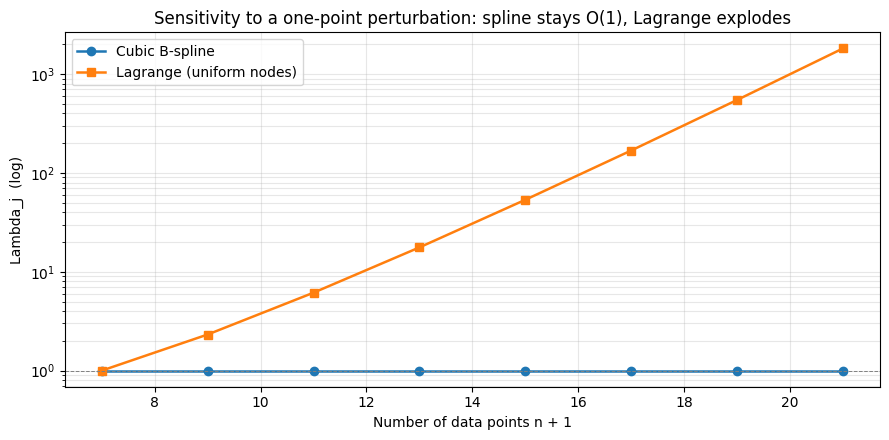

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogy(df_grow["n+1 = data points"], df_grow["Lambda_j (spline)"],
            "o-", lw=1.8, label="Cubic B-spline")
ax.semilogy(df_grow["n+1 = data points"], df_grow["Lambda_j (Lagrange)"],
            "s-", lw=1.8, label="Lagrange (uniform nodes)")
ax.axhline(1.0, color="gray", lw=0.7, ls="--")
ax.set_xlabel("Number of data points n + 1")
ax.set_ylabel("Lambda_j  (log)")
ax.set_title("Sensitivity to a one-point perturbation: spline stays O(1), Lagrange explodes")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

**1. 한 점 섭동의 자취 = 영향 함수의 그래프.** 위 패널의 *차이 곡선* 은 정의상 *$\delta \cdot L_j(x)$* — 따라서 그 모양이 곧 *보간 연산자의 한 점 감응도*. cubic B-spline 은 좁은 *국소 종*, Lagrange 는 *전구간 진동* 으로 정면 대비된다.

**2. $\Lambda_j$ — 정량적 격차.** $n + 1 = 11$ 일 때 이미 cubic B-spline 의 $\Lambda_j \approx \mathcal O(1)$ (약 1.0 안팎), Lagrange 의 $\Lambda_j$ 는 *수 배 ~ 수십 배* 까지 커진다. 데이터 점 수를 늘릴수록 ($n + 1 = 6 \to 20$) Lagrange 의 $\Lambda_j$ 가 *지수적으로* 증가하는 반면, B-spline 의 $\Lambda_j$ 는 *1 근방* 에서 거의 변하지 않는다 — semilog 그림에서 두 곡선의 *기울기 차이* 가 명확히 보인다.

**3. *영향이 미치는 영역의 길이*.** $|\Delta| > 0.05 \cdot |\delta|$ 인 구간의 길이로 *국소성 지표* 를 측정하면, cubic B-spline 은 $x_j$ 주변 *약 $4h$ 구간* 만 (= $\operatorname{supp} B_{i,3}$ 의 폭), Lagrange 는 *거의 전체 도메인* 이 영향을 받는다. 표의 *fraction of domain affected* 열에서 후자는 0.9 이상.

**4. 왜 중요한가.** 실제 측정 데이터에는 *잡음* 이 항상 섞여 있고, 잡음은 *각 점의 작은 섭동* 으로 모델링된다. cubic B-spline 은 각 잡음을 *그 자리에 가둬* 두는 반면, 전역 다항식은 *전체 모양을 흔든다*. 데이터 점 수가 늘수록 후자는 *Runge 메커니즘* (= Lagrange 영향 함수가 끝점에서 폭주) 으로 *재앙적* 으로 나빠진다.

> **결론.** *지역 지지* 는 단순히 기저의 모양이 좁다는 뜻이 아니라 **보간 연산자가 데이터 한 점의 변화를 그 점 근방에 가두는 안정성** 의 다른 표현이다. B-spline 의 *robustness* 는 여기서 온다.

**다음 (Problem 3):** *지역 지지* 가 *띠 행렬 보간 시스템* 으로 어떻게 번역되는지 — cubic B-spline 보간 시스템을 직접 풀고, Day 24 cubic spline 과 같은 $\mathcal O(h^4)$ 수렴을 측정하며, *variation-diminishing* (진동을 늘리지 않음) 도 함께 본다.
